In [19]:
import numpy as np
from scipy import signal

def complex_chirp(n_samples, f0, f1, fs, phi0=0):
  """
  Generate a complex chirp signal.

  Args:
    n_samples: Number of samples.
    f0: Start frequency (Hz).
    f1: End frequency (Hz).
    fs: Sampling rate (Hz).
    phi0: Initial phase (radians).

  Returns:
    Complex chirp signal (numpy array).
  """

  # Create the time vector.
  t = np.arange(n_samples) / fs

  # Calculate the instantaneous frequency at each time point.
  f_inst = np.linspace(f0, f1, n_samples)

  # Calculate the phase at each time point.
  phase = 2 * np.pi * np.cumsum(f_inst) * (t[1] - t[0]) + phi0

  # Generate the complex chirp signal.
  chirp = np.exp(1j * phase)

  return chirp

import matplotlib.pyplot as plt

def plot_chirp_frequency(chirp, fs):
  """
  Plots the instantaneous frequency of a chirp signal over time.

  Args:
    chirp: Complex chirp signal (numpy array).
    fs: Sampling rate (Hz).
  """

  # Calculate the instantaneous frequency using the derivative of the phase.
  phase = np.unwrap(np.angle(chirp))
  inst_freq = fs * np.diff(phase) / (2 * np.pi)

  # Create the time vector for the instantaneous frequency.
  t = np.arange(len(inst_freq)) / fs

  # Plot the instantaneous frequency.
  plt.plot(t, inst_freq)
  plt.xlabel("Time (s)")
  plt.ylabel("Instantaneous Frequency (Hz)")
  plt.title("Chirp Frequency Over Time")
  plt.grid(True)
  plt.show()

def add_noise_and_phase_shift(signal, noise_std, phase_shift):
  """Adds Gaussian noise and phase shift to a complex signal.

  Args:
    signal: The complex input signal (numpy array).
    noise_std: The standard deviation of the Gaussian noise.
    phase_shift: The phase shift in radians.

  Returns:
    The noisy and phase-shifted complex signal (numpy array).
  """

  # Add Gaussian noise to the signal.
  noise = np.random.normal(0, noise_std, len(signal))
  noisy_signal = signal + noise

  # Add phase shift to the signal
  phase_shifted_signal = noisy_signal * np.exp(1j * phase_shift)

  return phase_shifted_signal

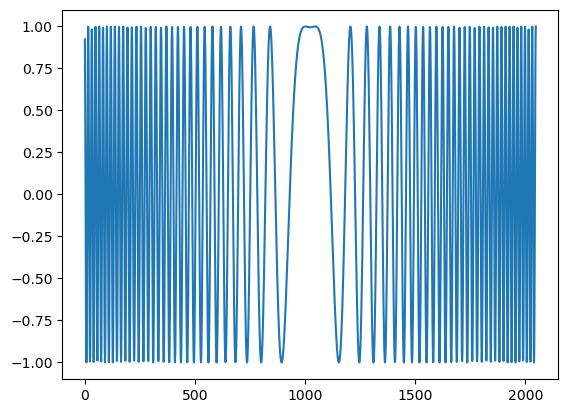

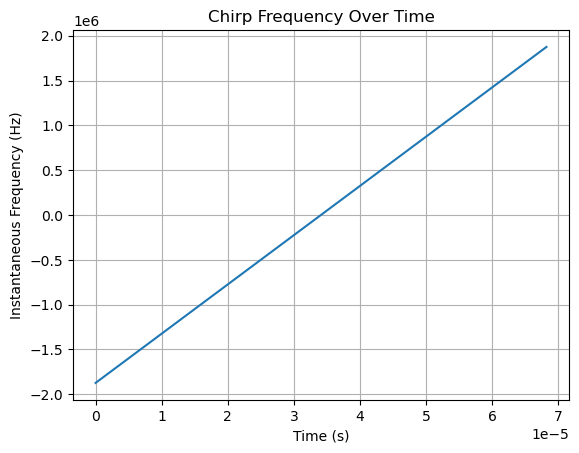

In [18]:
aChirp = complex_chirp(2048, -2.5e6, 2.5e6, 40e6)
noisy_chirp = 0.5*add_noise_and_phase_shift(aChirp, 0.5, 3)
#plt.plot(np.real(noisy_chirp))
plt.plot(np.real(aChirp))
plt.figure()
plot_chirp_frequency(aChirp,30e6)

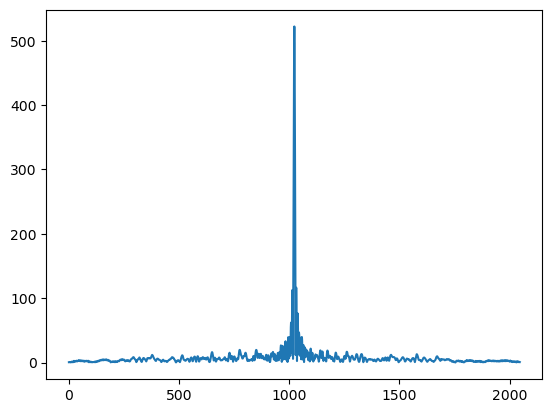

In [65]:
mf_output = signal.correlate(noisy_chirp,aChirp)
plt.plot(np.abs(mf_output))

In [51]:
np.angle(mf_output[np.argmax(np.abs(mf_output))])

3.022578461731157